# Master Pendulum: Switching and Contact-Aware Modes

This notebook uses the actual `MasterPendulum` class to demonstrate mode selection,
hysteresis, and contact-aware switching.


## Overview

1. Configure a contact-enabled FEM pendulum as the reference model.
2. Instantiate `MasterPendulum` and initialize it.
3. Set a contact-aware `mode_selector` and hysteresis.
4. Simulate and inspect synchronization events.


## Learning Goals

- Understand how to configure the `MasterPendulum` for contact-aware switching.
- Understanding effects of hysteresis and dwell time on mode switching.

## Prerequisites

You should be familiar with the FMU, OpenSim, and FEM pendulum components.
This notebook focuses on switching behavior and does not re-derive the models.


In [1]:
from pathlib import Path
import sys
_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import opensim as osim

osim.Logger.setLevelString("Warn")

from demos.ControlledPendulum.src.master_pendulum.orchestration.master_pendulum import MasterPendulum
from demos.ControlledPendulum.src.master_pendulum.components.fem import pendulum_config as config
from syssimx.core.multi_comp import Hysteresis
from syssimx import System
from syssimx.system.connection import EventConnection

In [3]:
import logging

logging.basicConfig(
    level=logging.WARNING,  # keep third-party loggers quiet
    format="[%(module)s] %(levelname)s: %(message)s",
)
# Enable debug output for the syssimx package
logging.getLogger("syssimx").setLevel(logging.DEBUG)

## Configure FEM Parameters

We enable contact so the `MasterPendulum` uses its contact-aware switching logic.
The FEM model acts as the reference for mass/inertia/length synchronization.


In [4]:
mesh_params = config.MeshParameters()

init_params = config.InitialConditionParameters()
init_params.angular_position_deg = np.rad2deg(0.3) # Initial angle

sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 1
sim_params.with_contact = True
sim_params.use_gravity = True

contact_params = config.ContactParameters()
contact_params.kn = 2e9

anim_params = config.AnimationParameters()
anim_params.animate = False

fem_parameters = {
    'contact_params': contact_params,
    'init_params': init_params,
    'sim_params': sim_params,
    'anim_params': anim_params,
    'mesh_params': mesh_params,
}


## Instantiate MasterPendulum

Initialization will:
- initialize FEM first,
- synchronize parameters to FMU and OpenSim,
- select the contact-aware mode selector if contact is enabled.


In [5]:
pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FMU")

pendulum.set_parameters(**{"FEM": fem_parameters})
pendulum.initialize(t0=0.0)

In [6]:
def wall_contact_event_indicator(pendulum: MasterPendulum):
    theta_wall = 0
    theta_pendulum = pendulum.get_outputs()['theta']
    return theta_pendulum - theta_wall

pendulum.add_event_indicator(name="wall_hit",
                             func=wall_contact_event_indicator,
                             direction=-1)

## Mode Selector and Hysteresis

We are using the default mode selector to use contact gap distance for switching.
In this scenario the `MasterPendulum` will switch to FMU mode when the pendulum is far from the wall, in the intermediate gap range it will use the OpenSim model, and when in contact it will use the FEM model.

This kind of mode selector is computationally expensive since it requires for each step to update the internal grid functions of the FEM model to compute the contact gap distance. In practice, you would likely want to use a more efficient switching criterion (e.g. based on the pendulum angle or velocity) and only update the FEM state and compute the gap distance when close to the wall.

If there is no contact, the mode selector will return "FMU".

```python
    def _gap_based_mode_selector(self, t: float, state: dict[str, Any]) -> str:
        """
        Select mode based on current angular position (theta) with hysteresis to prevent rapid switching.
        """
        theta_value = self.outputs["theta"].get()
        if theta_value is None:
            return self.active_mode  # not yet initialized; keep current mode
        theta = theta_value.magnitude if hasattr(theta_value, "magnitude") else float(theta_value)

        theta_abs_deg = abs(np.rad2deg(theta))

        # Mode selection based on angular position thresholds
        if theta_abs_deg > 15:
            return "FMU"
        elif theta_abs_deg > np.rad2deg(0.075):
            return "OpenSim"
        else:
            return "FEM"

Additionally, we set a hysteresis dwell time to prevent rapid switching when the pendulum is near the switching thresholds.

In [7]:
dwell_time = 0.05
pendulum.hysteresis = Hysteresis(dwell_time=dwell_time)

## Setup System

In [8]:
system = System(name="PendulumSystem")

system.add_component(pendulum)

event_connection = EventConnection(
    src_comp=pendulum.name, src_port=pendulum.output_specs['wall_hit'].name,
    dst_comp=pendulum.name, dst_port=pendulum.input_specs['omega_invert'].name
)

system.add_event_connection(event_connection)

## Simulate and Record Synchronization Events

We step the system, log the active mode, and inspect `sync_events` to verify
that switching preserves the shared state.


In [9]:
pendulum.setup_monitoring()
pendulum.display_monitoring()

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

<netgen.webgui.WebGuiWidget>: Run `pip install anywidget` to enable WebGuiWidget in Jupyter

![Pendulum Monitoring](pendulum_monitoring.png)

**Figure:** Pendulum Monitoring Dashboard



The figure above shows the pendulum monitoring dashboard, which includes:

**Simulation Status**:
- Current time and final time $t$.
- Current time step size $dt$.
- Active mode (FMU, OpenSim, or FEM).

**Input Signals**:
- Current applied torque $\tau$.

**Output Signals**:
- Angular position $\theta$
- Angular velocity $\dot{\theta}=\omega$
- Angular acceleration $\ddot{\theta}=\alpha$

**Stress Visualization**:
- The current normalized Second Piola-Kirchhoff stress distribution in the FEM model, which indicates where the pendulum is experiencing high stress (e.g. due to contact with the wall or due to the torque application).


In [10]:
system.initialize(t0=0.0)

system.algorithm.record_internal_steps = False
system.algorithm.event_dedup_tol = 5e-4
system.algorithm.tol_time = 1e-5
system.algorithm.tol_value = 5e-5

In [11]:
print(system.describe())
result = system.run(t0=0.0, tf=sim_params.t_end, dt=sim_params.tau)


[system] INFO: Starting simulation run from t=0.0 to t=1 with dt=0.01


System 'PendulumSystem'
  Algorithm: HybridAlgorithm
  Initialized: True
  Components (1):
    - MasterPendulum (MasterPendulum): 2 in / 4 out [direct feedthrough, state events]
  Connections (0):
  Event connections (1):
    - MasterPendulum.wall_hit -> MasterPendulum.omega_invert
  Execution order:
    Generation 0: MasterPendulum
  Algebraic loops: none detected


[multi_comp] INFO: [MasterPendulum] Switching: FMU to OpenSim @ t=0.0700s


[multi_comp] INFO: [MasterPendulum] Switching: OpenSim to FEM @ t=0.2000s


[hybrid] DEBUG: Internal hint: MasterPendulum.wall_hit in [0.23900000, 0.23910000]


...

[hybrid] DEBUG: Events grouped by listener: {'MasterPendulum': ['wall_hit']}


[hybrid] INFO: ================================================================================


[multi_comp] INFO: [MasterPendulum] Switching: FEM to OpenSim @ t=0.7400s


[multi_comp] INFO: [MasterPendulum] Switching: OpenSim to FMU @ t=0.8700s


[system] INFO: Simulation completed in 337.56 seconds


In [12]:
pendulum.fem.animate_stress()

<netgen.webgui.WebGuiWidget>: Run `pip install anywidget` to enable WebGuiWidget in Jupyter

## Visualize Mode Switching

The registered `MasterPendulum` trajectory and event log come from `result`. Per-backend histories are used only to show which internal model supplied each segment.


In [13]:
t_vals, data = result["MasterPendulum"]
q_vals = data["theta"]
omega_vals = data["omega"]
alpha_vals = data["alpha"]

# Inactive backends are internal to MasterPendulum and are not registered as
# top-level System components, so their diagnostic histories are read directly.
t_vals_fem, data_fem = pendulum.fem.get_history_arrays()
q_vals_fem = data_fem["theta"]
omega_vals_fem = data_fem["omega"]
t_vals_opensim, data_opensim = pendulum.opensim.get_history_arrays()
q_vals_opensim = data_opensim["theta"]
omega_vals_opensim = data_opensim["omega"]
t_vals_fmu, data_fmu = pendulum.fmu.get_history_arrays()
q_vals_fmu = data_fmu["theta"]
omega_vals_fmu = data_fmu["omega"]

event_times = (result.events or {}).get(("MasterPendulum", "wall_hit"), [])
t_event = event_times[0] if event_times else None

print(f"\nDetected {len(event_times)} events")
if t_event is not None:
    print(f"First event at t = {t_event.t:.8f} s")



Detected 2 events
First event at t = 0.23902500 s


In [14]:
mode_styles = {
    "FMU": dict(
        marker="s",
        color='orange',
        linestyle="None",
        markersize=3.2,
        label="FMU",
    ),
    "OpenSim": dict(
        marker="^",
        color='green',
        linestyle="None",
        markersize=3.2,
        label="OpenSim",
    ),
    "FEM": dict(
        marker="o",
        color='blue',
        linestyle="None",
        markersize=3.2,
        label="FEM",
    ),
}

event_style = dict(
    color="#B22222",
    linestyle=":",
    linewidth=1.8,
    label="Event time",
)

wall_style = dict(
    color="0.15",
    linestyle="--",
    linewidth=1.2,
    label="Wall position",
)

grid_style = dict(color="0.85", linewidth=0.7)


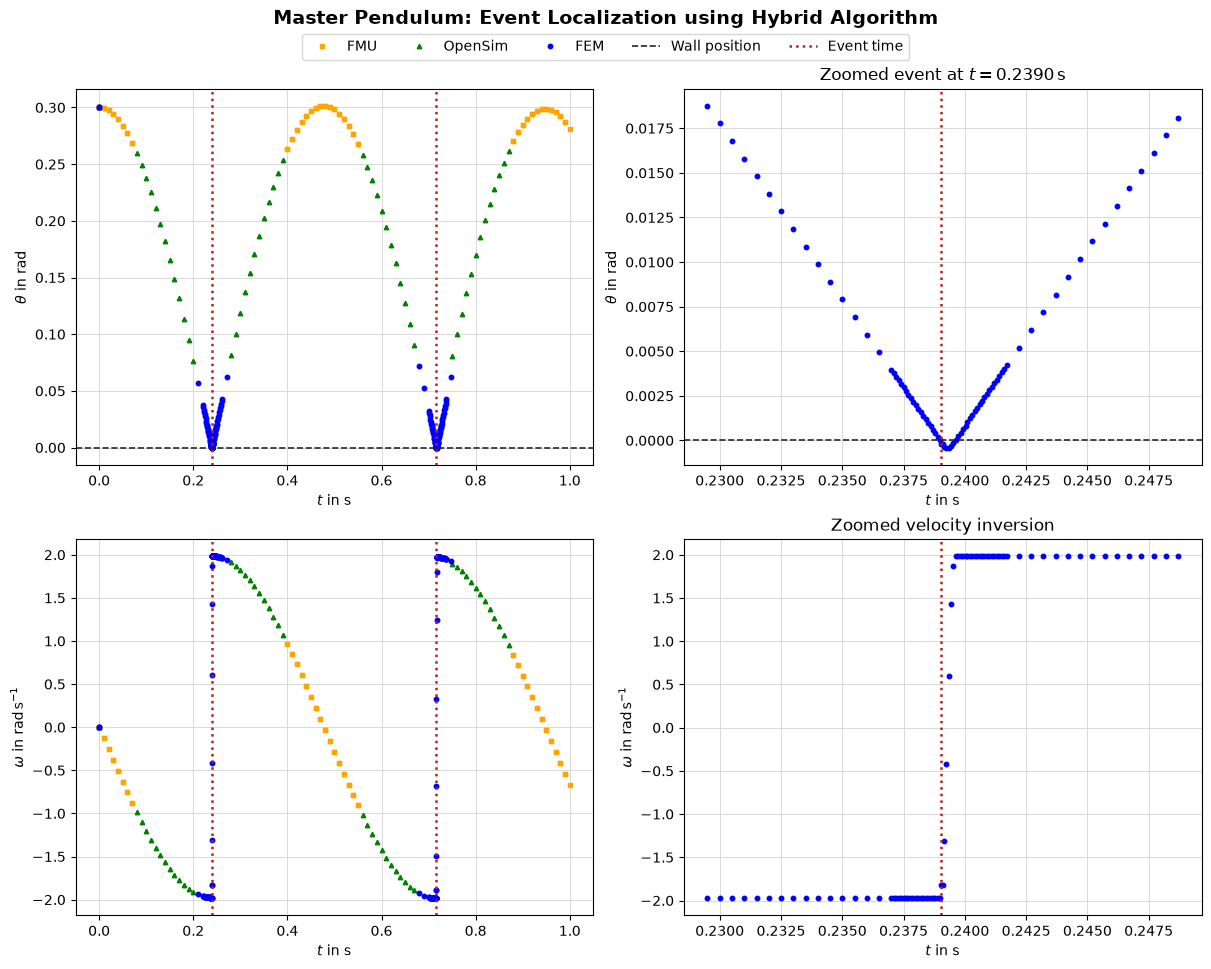

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

fig.suptitle(
    "Master Pendulum: Event Localization using Hybrid Algorithm",
    fontweight="bold",
    fontsize=14,
    y=1.06,
)

if t_event is not None:
    zoom_window = 0.01
    mask = (t_vals_fem >= t_event.t - zoom_window) & (t_vals_fem <= t_event.t + zoom_window)

# --- Full angle trajectory --------------------------------------------
axs[0, 0].plot(t_vals_fmu, q_vals_fmu, **mode_styles["FMU"])
axs[0, 0].plot(t_vals_opensim, q_vals_opensim, **mode_styles["OpenSim"])
axs[0, 0].plot(t_vals_fem, q_vals_fem, **mode_styles["FEM"])
axs[0, 0].axhline(0, **wall_style)

axs[0, 0].axvline(event_times[0].t, **event_style)
axs[0, 0].axvline(event_times[1].t, **{**event_style, "label": "_nolegend_"})

axs[0, 0].set_ylabel(r"$\theta$ in $\mathrm{rad}$")
axs[0, 0].set_xlabel(r"$t$ in $\mathrm{s}$")

# --- Zoomed angle near event ------------------------------------------
if t_event is not None:
    axs[0, 1].plot(
        t_vals_fem[mask],
        q_vals_fem[mask],
        **{**mode_styles["FEM"], "label": "_nolegend_"},
    )
    axs[0, 1].axhline(0, **{**wall_style, "label": "_nolegend_"})
    axs[0, 1].axvline(t_event.t, **{**event_style, "label": "_nolegend_"})
    axs[0, 1].set_title(rf"Zoomed event at $t={t_event.t:.4f}\,\mathrm{{s}}$")

axs[0, 1].set_ylabel(r"$\theta$ in $\mathrm{rad}$")
axs[0, 1].set_xlabel(r"$t$ in $\mathrm{s}$")

# --- Full angular velocity --------------------------------------------
axs[1, 0].plot(
    t_vals_fmu,
    omega_vals_fmu,
    **{**mode_styles["FMU"], "label": "_nolegend_"},
)
axs[1, 0].plot(
    t_vals_opensim,
    omega_vals_opensim,
    **{**mode_styles["OpenSim"], "label": "_nolegend_"},
)
axs[1, 0].plot(
    t_vals_fem,
    omega_vals_fem,
    **{**mode_styles["FEM"], "label": "_nolegend_"},
)

axs[1, 0].axvline(event_times[0].t, **{**event_style, "label": "_nolegend_"})
axs[1, 0].axvline(event_times[1].t, **{**event_style, "label": "_nolegend_"})

axs[1, 0].set_ylabel(r"$\omega$ in $\mathrm{rad\,s^{-1}}$")
axs[1, 0].set_xlabel(r"$t$ in $\mathrm{s}$")

# --- Zoomed velocity near event ---------------------------------------
if t_event is not None:
    axs[1, 1].plot(
        t_vals_fem[mask],
        omega_vals_fem[mask],
        **{**mode_styles["FEM"], "label": "_nolegend_"},
    )
    axs[1, 1].axvline(t_event.t, **{**event_style, "label": "_nolegend_"})
    axs[1, 1].set_title("Zoomed velocity inversion")

axs[1, 1].set_ylabel(r"$\omega$ in $\mathrm{rad\,s^{-1}}$")
axs[1, 1].set_xlabel(r"$t$ in $\mathrm{s}$")

# --- Shared formatting ------------------------------------------------
for ax in axs.flat:
    ax.grid(True, **grid_style)

# One clean legend from first panel only.
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=5,
    frameon=True,
)

plt.show()


## Conclusion

- `System.run()` returns the registered wrapper trajectory and the localized contact events.
- Internal backend histories remain useful diagnostics because inactive models are not top-level system components.
- Hysteresis prevents rapid mode changes while state synchronization keeps the shared pendulum state continuous.

Next: {doc}`../../05_case_study/05_multi_model_switching` applies the same mechanism in the complete controlled-pendulum case study.
